# Klasifikasi Dua Kelas dengan Logistic Regression
## Tema: Deteksi Komentar Toxic / Non-Toxic

**Nama:** Mochammad Lintar Arya Dwiputra  
**NIM:** 2024081032  
**Mata Kuliah:** Machine Learning  
**Pertemuan:** 12 — Logistic Regression dan Two-Class Classification

---
### Bukti Pemahaman Materi

Berdasarkan Modul 12 dan materi video Pertemuan 12, logistic regression adalah algoritma klasifikasi linear yang:
- Menghasilkan **probabilitas** (bukan keputusan langsung seperti perceptron)
- Menggunakan **fungsi sigmoid** untuk mengubah skor linear menjadi nilai antara 0 dan 1
- Menentukan kelas akhir berdasarkan threshold (biasanya 0.5)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Library berhasil diimport!")


Library berhasil diimport!


## 1. Dataset — 15 Data Komentar Media Sosial

In [8]:
data = {
    "komentar": [
        "kontennya bagus dan informatif banget",
        "lu goblok banget siapa yang minta pendapat lu",
        "saya tidak setuju tapi terima kasih sudah berbagi",
        "akun paling tolol yang pernah saya lihat di internet",
        "penjelasannya sangat membantu dan mudah dipahami",
        "isi videonya sampah nggak ada gunanya",
        "sangat bermanfaat untuk pemula seperti saya",
        "jelek dan tidak jelas mending hapus aja",
        "terima kasih sudah membuat konten yang edukatif",
        "dasar bodoh nggak tahu apa apa sok pinter",
        "konten keren terus berkarya semoga sukses",
        "mending diam dah kalau nggak ngerti apa apa",
        "bagus sekali penjelasannya sangat detail dan lengkap",
        "brengsek banget kelakuan lu nyebelin",
        "sukses terus channelnya saya selalu nantikan kontennya",
    ],
    "label": [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
}
df = pd.DataFrame(data)
df["kelas"] = df["label"].map({0: "Non-toxic", 1: "Toxic"})
print(df[["komentar", "kelas"]].to_string(index=False))


                                              komentar     kelas
                 kontennya bagus dan informatif banget Non-toxic
         lu goblok banget siapa yang minta pendapat lu     Toxic
     saya tidak setuju tapi terima kasih sudah berbagi Non-toxic
  akun paling tolol yang pernah saya lihat di internet     Toxic
      penjelasannya sangat membantu dan mudah dipahami Non-toxic
                 isi videonya sampah nggak ada gunanya     Toxic
           sangat bermanfaat untuk pemula seperti saya Non-toxic
               jelek dan tidak jelas mending hapus aja     Toxic
       terima kasih sudah membuat konten yang edukatif Non-toxic
             dasar bodoh nggak tahu apa apa sok pinter     Toxic
             konten keren terus berkarya semoga sukses Non-toxic
           mending diam dah kalau nggak ngerti apa apa     Toxic
  bagus sekali penjelasannya sangat detail dan lengkap Non-toxic
                  brengsek banget kelakuan lu nyebelin     Toxic
sukses terus channelnya s

## 2. Fitur Manual (Ilustrasi)

In [9]:
kata_kasar   = ["goblok","tolol","bodoh","brengsek","sampah","jelek","nyebelin","dasar","sok"]
kata_positif = ["bagus","membantu","bermanfaat","edukatif","informatif","sukses","keren","detail","lengkap","mudah"]

df["f_kata_kasar"]   = df["komentar"].apply(lambda t: int(any(k in t for k in kata_kasar)))
df["f_kata_positif"] = df["komentar"].apply(lambda t: int(any(k in t for k in kata_positif)))
df["f_panjang"]      = df["komentar"].apply(lambda t: len(t.split()))

print(df[["komentar","f_kata_kasar","f_kata_positif","f_panjang","kelas"]].to_string(index=False))


                                              komentar  f_kata_kasar  f_kata_positif  f_panjang     kelas
                 kontennya bagus dan informatif banget             0               1          5 Non-toxic
         lu goblok banget siapa yang minta pendapat lu             1               0          8     Toxic
     saya tidak setuju tapi terima kasih sudah berbagi             0               0          8 Non-toxic
  akun paling tolol yang pernah saya lihat di internet             1               0          9     Toxic
      penjelasannya sangat membantu dan mudah dipahami             0               1          6 Non-toxic
                 isi videonya sampah nggak ada gunanya             1               0          6     Toxic
           sangat bermanfaat untuk pemula seperti saya             0               1          6 Non-toxic
               jelek dan tidak jelas mending hapus aja             1               0          7     Toxic
       terima kasih sudah membuat konten yang 

## 3. Training Model Logistic Regression

In [10]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["komentar"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=0, stratify=y
)

model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

print(f"Model berhasil dilatih!")
print(f"Jumlah data train : {X_train.shape[0]}")
print(f"Jumlah data test  : {X_test.shape[0]}")


Model berhasil dilatih!
Jumlah data train : 10
Jumlah data test  : 5


## 4. Evaluasi Model

In [11]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print("=== Hasil Evaluasi ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-toxic","Toxic"], zero_division=0))


=== Hasil Evaluasi ===
Accuracy : 1.00

Classification Report:
              precision    recall  f1-score   support

   Non-toxic       1.00      1.00      1.00         3
       Toxic       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



## 5. Visualisasi — Confusion Matrix

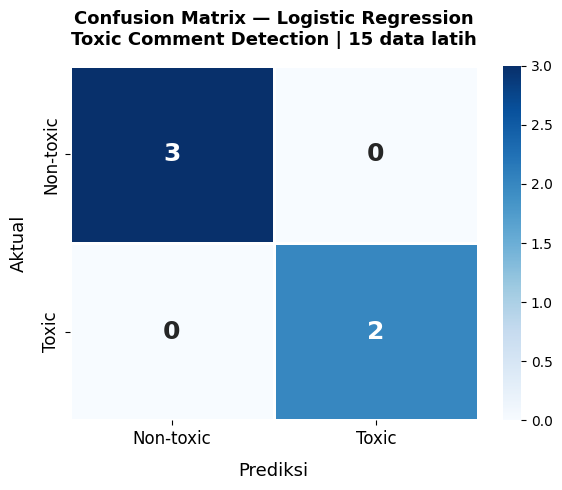

Confusion Matrix tersimpan: confusion_matrix.png


In [12]:
cm = confusion_matrix(y_test, y_pred)
labels = ["Non-toxic", "Toxic"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=2, linecolor='white',
    annot_kws={"size": 18, "weight": "bold"},
    cbar=True
)
ax.set_xlabel("Prediksi", fontsize=13, labelpad=10)
ax.set_ylabel("Aktual", fontsize=13, labelpad=10)
ax.set_title("Confusion Matrix — Logistic Regression\nToxic Comment Detection | 15 data latih", 
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion Matrix tersimpan: confusion_matrix.png")


## 6. Prediksi Komentar Baru

In [13]:
komentar_baru = [
    "videonya sangat menginspirasi dan bermanfaat",
    "nggak berguna banget konten sampah",
    "terima kasih sudah berbagi ilmu yang berharga",
    "dasar goblok nggak tahu malu",
    "penjelasan yang sangat detail dan mudah dipahami",
]

X_baru  = vectorizer.transform(komentar_baru)
pred    = model.predict(X_baru)
proba   = model.predict_proba(X_baru)
label_map = {0: "Non-toxic", 1: "Toxic"}

print("=== Prediksi Komentar Baru ===")
for i, k in enumerate(komentar_baru):
    print(f'Komentar : "{k}"')
    print(f'Prediksi : {label_map[pred[i]]}')
    print(f'Probabilitas → Non-toxic: {proba[i][0]:.2f} | Toxic: {proba[i][1]:.2f}')
    print("-" * 65)


=== Prediksi Komentar Baru ===
Komentar : "videonya sangat menginspirasi dan bermanfaat"
Prediksi : Non-toxic
Probabilitas → Non-toxic: 0.68 | Toxic: 0.32
-----------------------------------------------------------------
Komentar : "nggak berguna banget konten sampah"
Prediksi : Toxic
Probabilitas → Non-toxic: 0.37 | Toxic: 0.63
-----------------------------------------------------------------
Komentar : "terima kasih sudah berbagi ilmu yang berharga"
Prediksi : Non-toxic
Probabilitas → Non-toxic: 0.60 | Toxic: 0.40
-----------------------------------------------------------------
Komentar : "dasar goblok nggak tahu malu"
Prediksi : Toxic
Probabilitas → Non-toxic: 0.34 | Toxic: 0.66
-----------------------------------------------------------------
Komentar : "penjelasan yang sangat detail dan mudah dipahami"
Prediksi : Non-toxic
Probabilitas → Non-toxic: 0.69 | Toxic: 0.31
-----------------------------------------------------------------


## 7. Visualisasi — Probabilitas Prediksi Komentar Baru

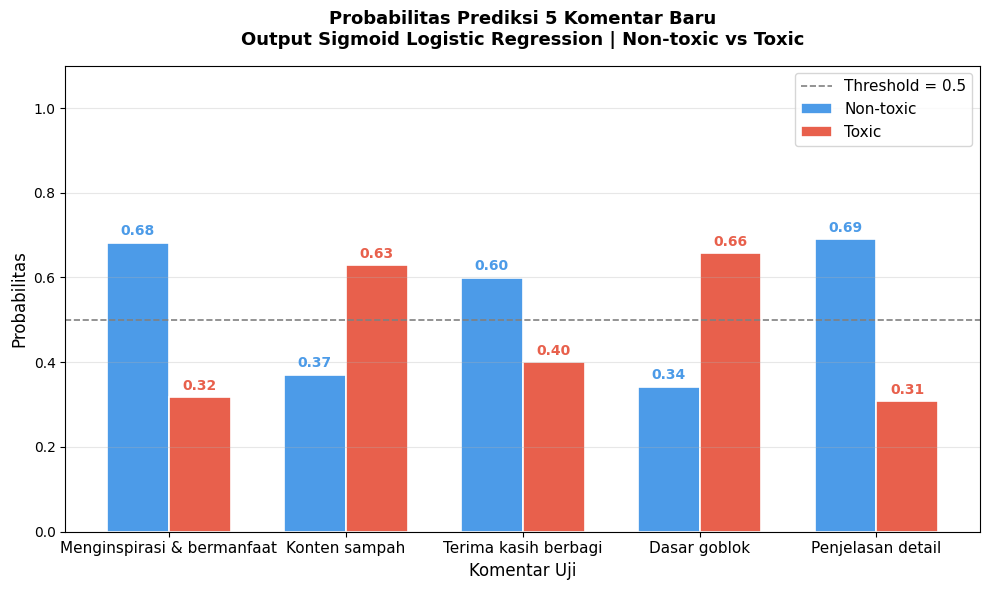

Chart probabilitas tersimpan: probabilitas_prediksi.png


In [14]:
komentar_baru = [
    "videonya sangat menginspirasi dan bermanfaat",
    "nggak berguna banget konten sampah",
    "terima kasih sudah berbagi ilmu yang berharga",
    "dasar goblok nggak tahu malu",
    "penjelasan yang sangat detail dan mudah dipahami",
]
X_baru  = vectorizer.transform(komentar_baru)
pred    = model.predict(X_baru)
proba   = model.predict_proba(X_baru)

short_labels = [
    "Menginspirasi & bermanfaat",
    "Konten sampah",
    "Terima kasih berbagi",
    "Dasar goblok",
    "Penjelasan detail",
]

x = np.arange(len(short_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, proba[:, 0], width, label='Non-toxic', color='#4C9BE8', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, proba[:, 1], width, label='Toxic',     color='#E8604C', edgecolor='white', linewidth=1.2)

# Annotasi nilai di atas bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, color='#4C9BE8', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, color='#E8604C', fontweight='bold')

# Garis threshold 0.5
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.2, label='Threshold = 0.5')

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=11)
ax.set_ylabel("Probabilitas", fontsize=12)
ax.set_xlabel("Komentar Uji", fontsize=12)
ax.set_title("Probabilitas Prediksi 5 Komentar Baru\nOutput Sigmoid Logistic Regression | Non-toxic vs Toxic",
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("probabilitas_prediksi.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart probabilitas tersimpan: probabilitas_prediksi.png")


## 8. Kurva Fungsi Sigmoid

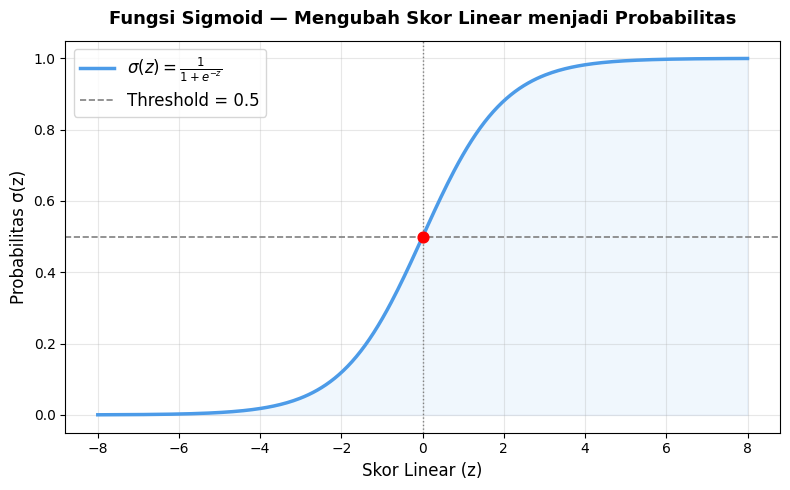

Kurva sigmoid tersimpan: sigmoid_curve.png


In [15]:
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z, sigmoid, color='#4C9BE8', linewidth=2.5, label=r'$\sigma(z) = \frac{1}{1+e^{-z}}$')
ax.fill_between(z, sigmoid, alpha=0.08, color='#4C9BE8')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Threshold = 0.5')
ax.axvline(0,   color='gray', linestyle=':',  linewidth=1.0)
ax.scatter([0], [0.5], color='red', zorder=5, s=60)

ax.set_xlabel("Skor Linear (z)", fontsize=12)
ax.set_ylabel("Probabilitas σ(z)", fontsize=12)
ax.set_title("Fungsi Sigmoid — Mengubah Skor Linear menjadi Probabilitas",
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("sigmoid_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Kurva sigmoid tersimpan: sigmoid_curve.png")


## 9. Kesimpulan

Logistic regression bekerja dengan menghitung skor linear dari fitur teks, lalu mengubah skor tersebut menjadi probabilitas menggunakan fungsi sigmoid. Kelas akhir ditentukan berdasarkan threshold 0.5 — jika probabilitas toxic ≥ 0.5 maka komentar diklasifikasikan sebagai toxic, dan sebaliknya.

**Kelebihan probabilitas dibanding keputusan keras (perceptron):**
- Model tidak hanya menjawab *"toxic atau tidak"*, tetapi memberikan **ukuran keyakinan**
- Misalnya: *"66% kemungkinan toxic"* → pengguna bisa atur threshold sesuai kebutuhan
- Membuat sistem moderasi lebih fleksibel, transparan, dan dapat disesuaikan
